In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")
print("✅ Libraries successfully loaded!")

✅ Libraries successfully loaded!


In [2]:
# CSV file usi folder mein honi chahiye
data = pd.read_csv('creditcard.csv').dropna()
print("Dataset Shape:", data.shape)
data.head() # Yeh data ki table dikhayega

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


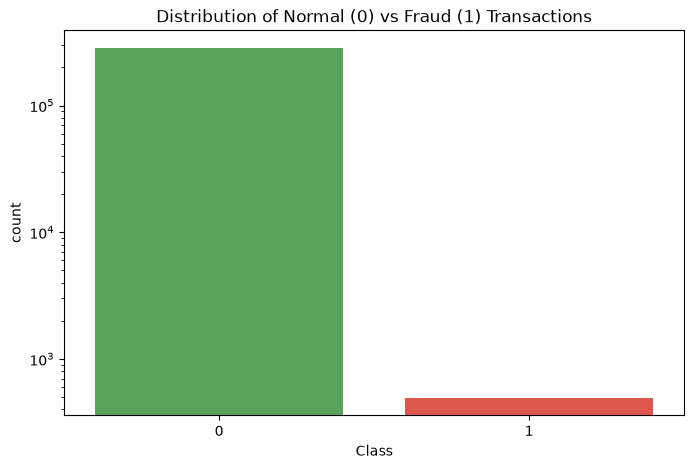

Class
0    284315
1       492
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=data, palette=['#4CAF50', '#F44336'])
plt.title('Distribution of Normal (0) vs Fraud (1) Transactions')
plt.yscale('log') # Log scale taaki choti fraud values bhi dikhein
plt.show()

print(data['Class'].value_counts())

In [4]:
print("Data train aur balance ho raha hai...")
X = data.drop('Class', axis=1)
y = data['Class']

# 80-20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_smote, y_train_smote)
print("✅ Model Trained Successfully!")

Data train aur balance ho raha hai...
✅ Model Trained Successfully!


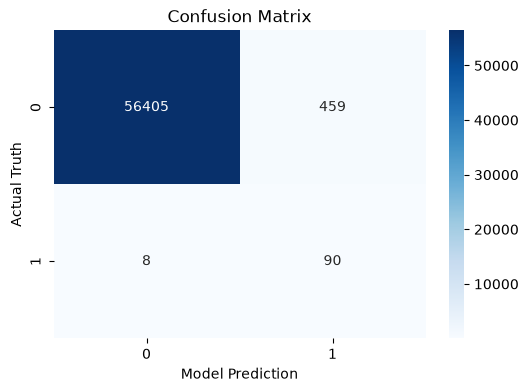


--- Detailed Score Card ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.92      0.28        98

    accuracy                           0.99     56962
   macro avg       0.58      0.96      0.64     56962
weighted avg       1.00      0.99      0.99     56962



In [5]:
y_pred = model.predict(X_test)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

print("\n--- Detailed Score Card ---")
print(classification_report(y_test, y_pred))

In [10]:
def check_fraud(transaction_values):
    # Data ko proper shape mein lana
    import numpy as np
    test_data = np.zeros(30)
    test_data[-1] = transaction_values['Amount'] # Amount aakhiri column hota hai
    test_data[0] = transaction_values['V1']
    test_data[1] = transaction_values['V2']
    
    prediction = model.predict([test_data])
    
    print("-" * 40)
    if prediction[0] == 1:
        print("🚨 RED ALERT: SUSPICIOUS TRANSACTION DETECTED!")
    else:
        print("✅ Transaction Successful. Safe.")
    print("-" * 40)

# Yahan values change karke run kijiye
check_fraud({"Amount": 987654321000, "V1": -7.5, "V2": 3.2})

----------------------------------------
✅ Transaction Successful. Safe.
----------------------------------------
